Phase 1 – Business Understanding
1.1 Background
Customer churn refers to the phenomenon where customers discontinue their relationship with a company or service provider. In the telecommunications industry, churn is a critical business metric because acquiring a new customer can cost five to seven times more than retaining an existing one (Reichheld & Schefter, 2000).

This project focuses on a fictional telecommunications company (IBM Telco Dataset) that offers phone and internet services to approximately 7,000 customers. The company has observed a churn rate of approximately 26.5%, meaning roughly one in four customers leaves within a given period.

1.2 Business Objectives
The primary business objective is to reduce customer churn by proactively identifying customers who are at high risk of cancelling their service, enabling the retention team to intervene with targeted offers or incentives.

The secondary objective is to understand the key drivers of churn i.e., which contract types, services, or demographic factors are most associated with customers leaving.

1.3 Success Criteria
From a business perspective, success means:

Identifying at least 75% of churners before they leave (high Recall).
Providing actionable insights into the top 3–5 drivers of churn.
From a technical perspective, success means:

Achieving an F1-Score ≥ 0.70 on the test set.
Comparing at least three different ML models and justifying the final model choice.
1.4 CRISP-DM Diagram
The six phases of CRISP-DM applied to this project are:

Phase	Description
1. Business Understanding	   Define the problem and success criteria
2. Data Understanding	       Explore and describe the dataset
3. Data Preparation	           Clean, encode and engineer features
4. Modelling	               Train and tune ML classification models
5. Evaluation	               Assess model performance and interpret results
6. Deployment	               Present findings and recommendations


Phase 2 – Data Understanding
2.1 Dataset Overview
The dataset used is the IBM Telco Customer Churn dataset, publicly available on Kaggle. It contains 7,043 rows and 21 columns, each row representing a unique customer.

Source: Kaggle – Telco Customer Churn

2.2 Variable Description
Variable	Type	Description
customerID	ID	Unique customer identifier
gender	Categorical	Male / Female
SeniorCitizen	Binary	1 = Senior, 0 = Not
Partner	Categorical	Has a partner? Yes/No
Dependents	Categorical	Has dependents? Yes/No
tenure	Numerical	Months as a customer
PhoneService	Categorical	Has phone service?
MultipleLines	Categorical	Multiple phone lines?
InternetService	Categorical	DSL / Fiber optic / No
OnlineSecurity	Categorical	Has online security add-on?
OnlineBackup	Categorical	Has online backup add-on?
DeviceProtection	Categorical	Has device protection?
TechSupport	Categorical	Has tech support?
StreamingTV	Categorical	Streams TV?
StreamingMovies	Categorical	Streams movies?
Contract	Categorical	Month-to-month / One year / Two year
PaperlessBilling	Categorical	Uses paperless billing?
PaymentMethod	Categorical	Electronic check / Mailed check / Bank transfer / Credit card
MonthlyCharges	Numerical	Monthly bill amount (USD)
TotalCharges	Numerical	Total amount charged (USD)
Churn	Target

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
df.head()

Dataset shape: (7043, 21)

Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ── 2.4 Basic Statistics ─────────────────────────────────────────────────────
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Descriptive Statistics (Numerical) ===")
df.describe()


=== Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


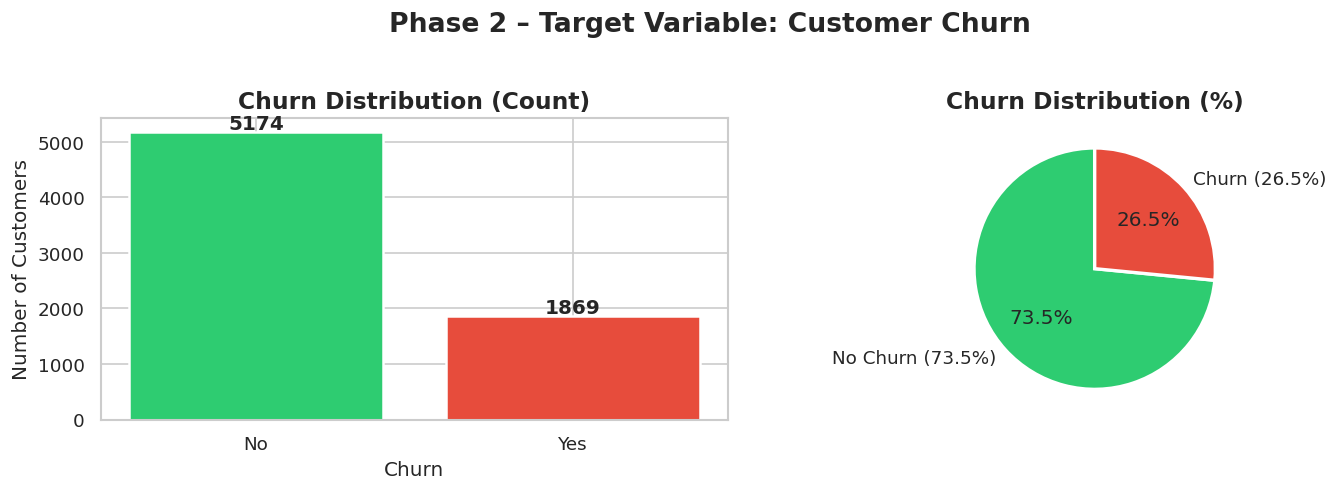


Observation: The dataset is IMBALANCED – only 26.5% of customers churned.
This means we must use SMOTE or class_weight='balanced' during modelling.


In [4]:
# ── 2.5 Target Variable Distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(churn_counts.values, labels=['No Churn (73.5%)', 'Churn (26.5%)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Phase 2 – Target Variable: Customer Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/01_churn_distribution.png', bbox_inches='tight')
plt.show()
print("\nObservation: The dataset is IMBALANCED – only 26.5% of customers churned.")
print("This means we must use SMOTE or class_weight='balanced' during modelling.")


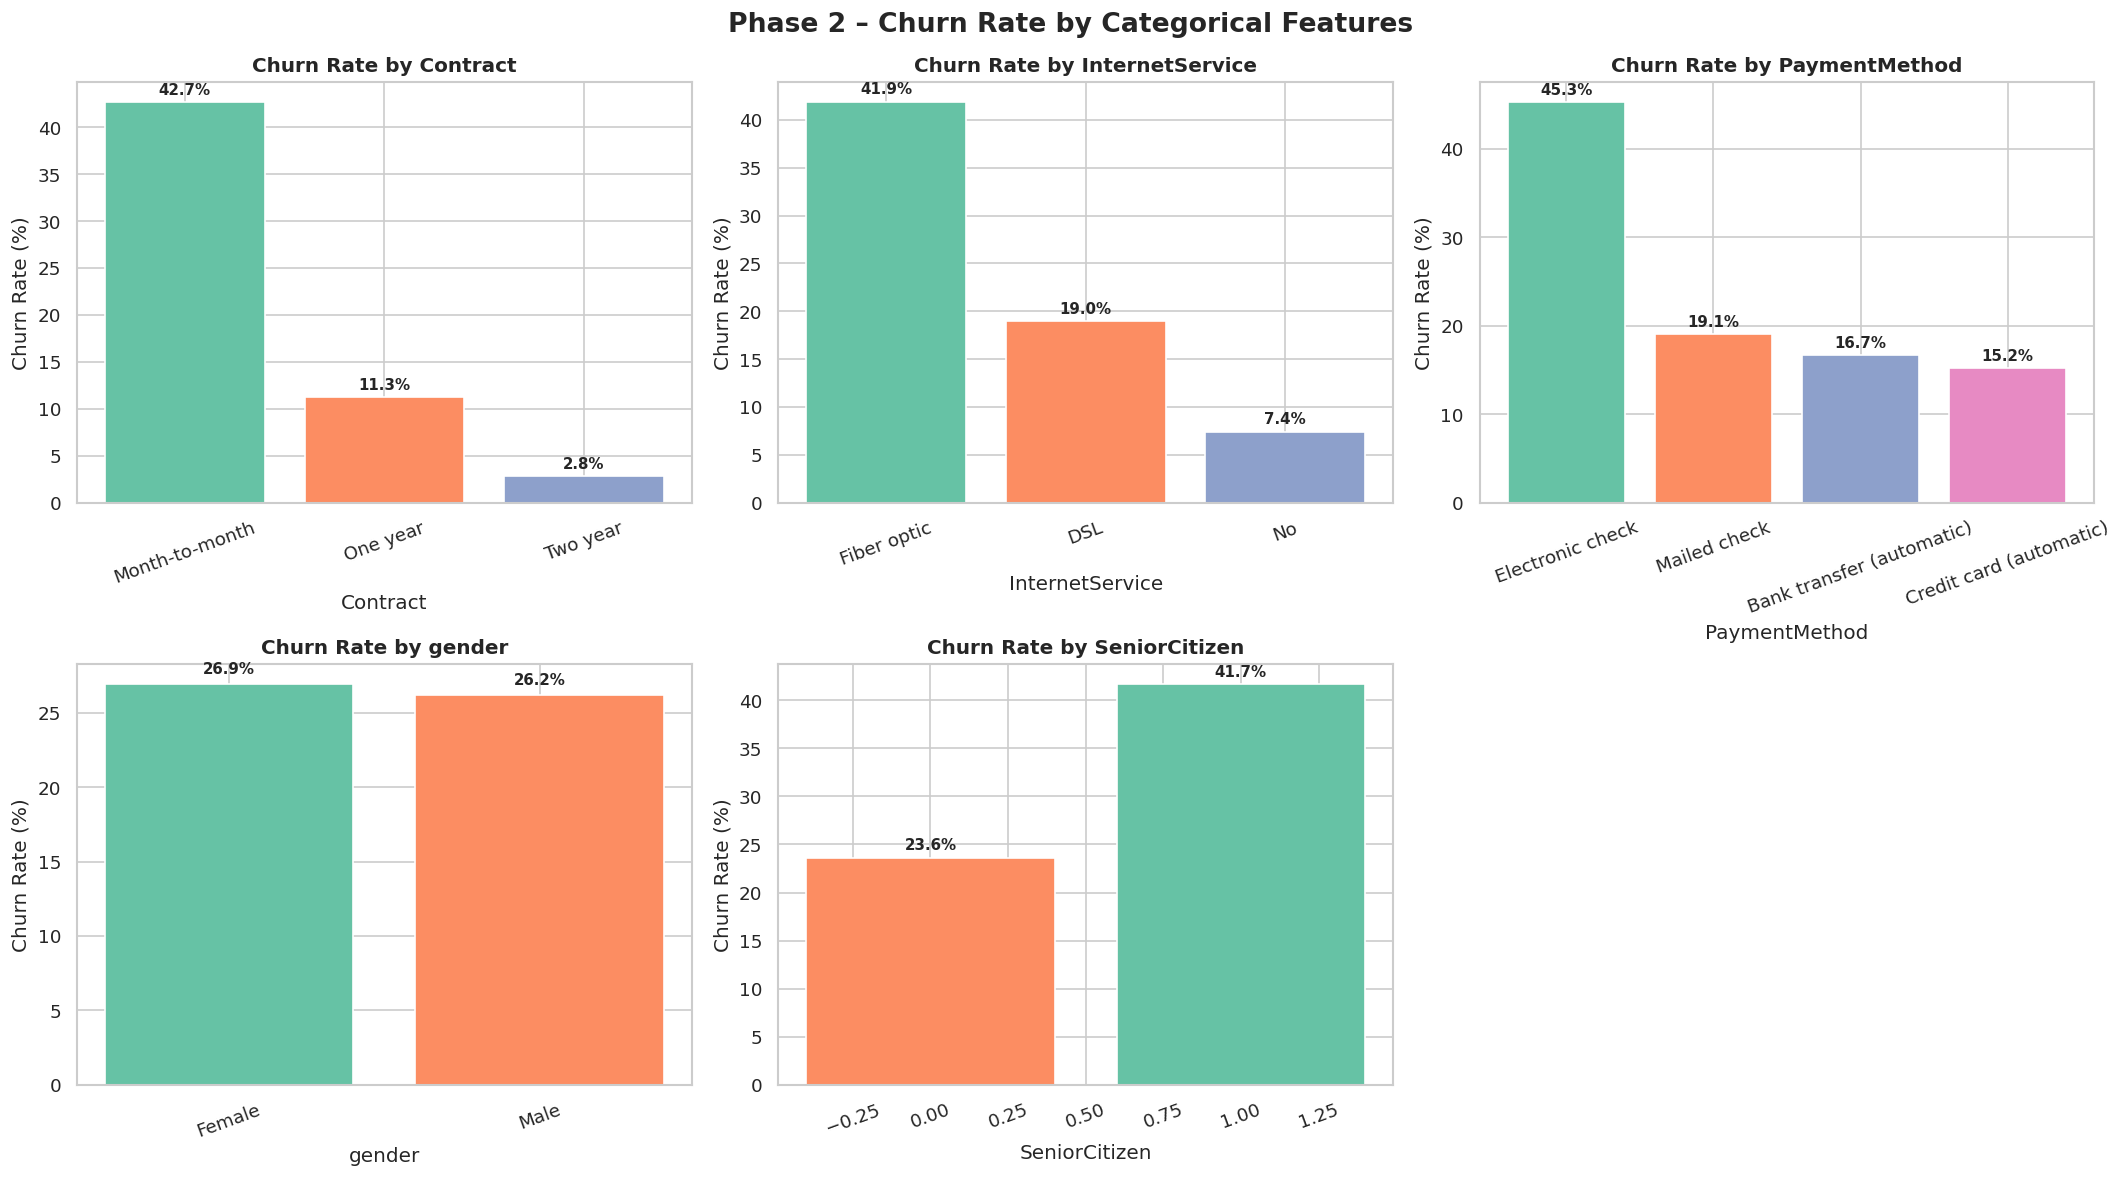

In [5]:
# ── 2.6 Churn by Key Categorical Variables ───────────────────────────────────
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender', 'SeniorCitizen']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    churn_rate.columns = [col, 'Churn Rate (%)']
    churn_rate = churn_rate.sort_values('Churn Rate (%)', ascending=False)

    bars = axes[i].bar(churn_rate[col], churn_rate['Churn Rate (%)'],
                       color=sns.color_palette('Set2', len(churn_rate)), edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=20)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Phase 2 – Churn Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/02_churn_by_category.png', bbox_inches='tight')
plt.show()


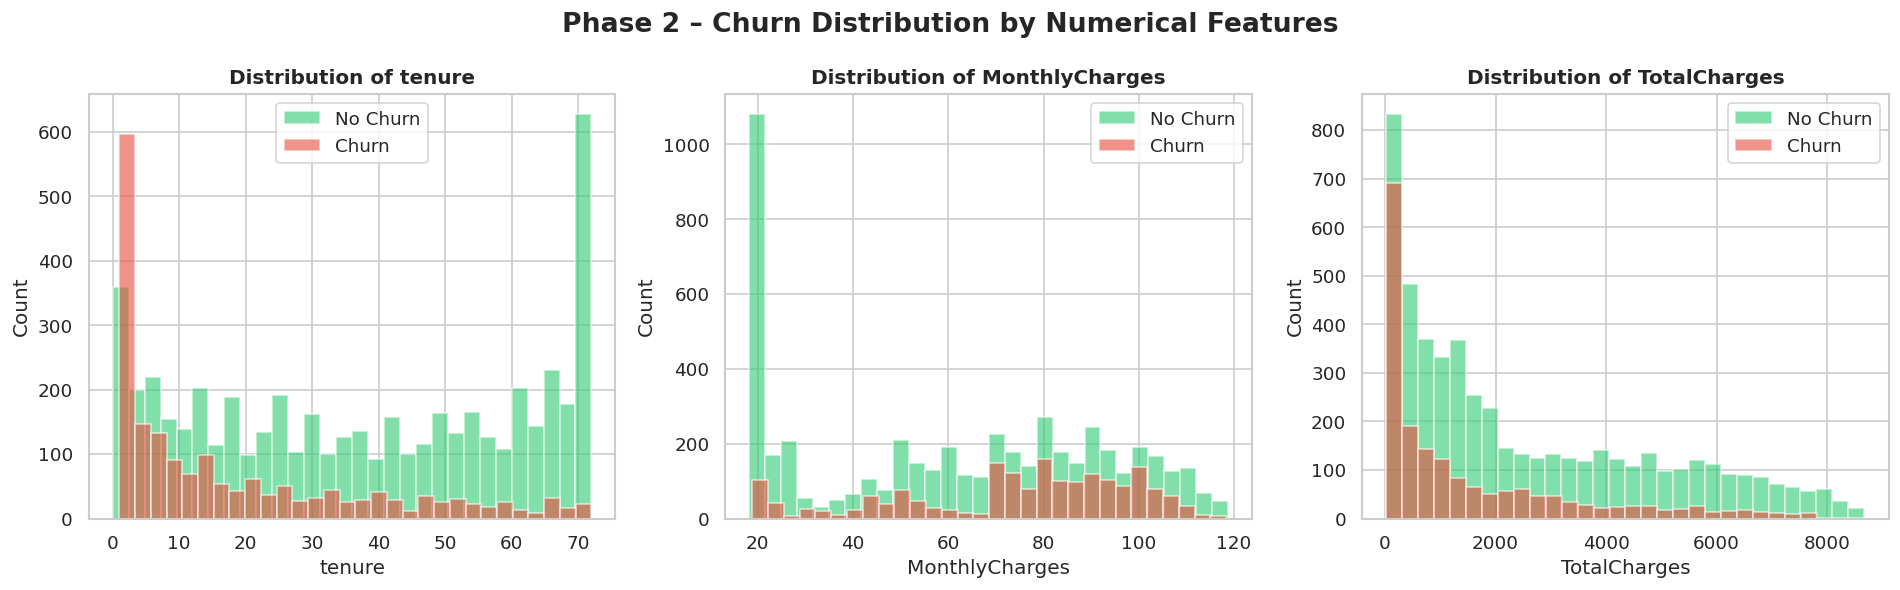

Key Observations:
  - Avg tenure (Churn=Yes): 18.0 months
  - Avg tenure (Churn=No):  37.6 months
  - Avg MonthlyCharges (Churn=Yes): $74.44
  - Avg MonthlyCharges (Churn=No):  $61.27


In [6]:
# ── 2.7 Churn by Numerical Variables ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Convert TotalCharges to numeric (it has some spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

for i, col in enumerate(num_cols):
    churned = df[df['Churn'] == 'Yes'][col].dropna()
    retained = df[df['Churn'] == 'No'][col].dropna()
    axes[i].hist(retained, bins=30, alpha=0.6, color='#2ecc71', label='No Churn', edgecolor='white')
    axes[i].hist(churned, bins=30, alpha=0.6, color='#e74c3c', label='Churn', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Phase 2 – Churn Distribution by Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/03_churn_by_numerical.png', bbox_inches='tight')
plt.show()

print("Key Observations:")
print(f"  - Avg tenure (Churn=Yes): {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"  - Avg tenure (Churn=No):  {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print(f"  - Avg MonthlyCharges (Churn=Yes): ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"  - Avg MonthlyCharges (Churn=No):  ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")


Phase 3 – Data Preparation
In this phase, we clean the data, handle data quality issues, encode categorical variables, and prepare the final feature matrix for modelling. This is typically the most time-consuming phase in any real-world data science project.

Steps performed:

Fix data type issues (TotalCharges stored as string)
Handle missing/null values
Drop irrelevant columns (customerID)
Encode binary categorical variables (Yes/No → 1/0)
One-Hot Encode multi-class categorical variables
Scale numerical features
Address class imbalance using SMOTE

In [7]:
# ── 3.1 Fix Data Types & Handle Missing Values ───────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

df_clean = df.copy()

# Fix TotalCharges: convert to numeric, fill NaN with median
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
missing_before = df_clean['TotalCharges'].isnull().sum()
median_val = df_clean['TotalCharges'].median()
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(median_val)
print(f"TotalCharges: {missing_before} missing values filled with median ({median_val:.2f})")

# Drop customerID (not a predictive feature)
df_clean.drop(columns=['customerID'], inplace=True)
print(f"\nDataset shape after dropping customerID: {df_clean.shape}")


TotalCharges: 11 missing values filled with median (1397.47)

Dataset shape after dropping customerID: (7043, 20)


In [8]:
# ── 3.2 Encode Target Variable ───────────────────────────────────────────────
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
print("Target variable encoded: Yes=1, No=0")
print(df_clean['Churn'].value_counts())


Target variable encoded: Yes=1, No=0
Churn
0    5174
1    1869
Name: count, dtype: int64


In [9]:
# ── 3.3 Encode Binary Categorical Variables ──────────────────────────────────
# Columns with Yes/No values
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Map Yes/No to 1/0; keep 'No phone service' / 'No internet service' as 0
for col in binary_cols:
    df_clean[col] = df_clean[col].map(lambda x: 1 if x == 'Yes' else 0)

# Gender: Female=0, Male=1
df_clean['gender'] = df_clean['gender'].map({'Female': 0, 'Male': 1})

# Fill any remaining NaN with 0 (safety net)
df_clean[binary_cols + ['gender']] = df_clean[binary_cols + ['gender']].fillna(0).astype(int)

print("Binary encoding done.")
print(df_clean[['gender', 'Partner', 'Dependents', 'Churn']].head())


Binary encoding done.
   gender  Partner  Dependents  Churn
0       0        1           0      0
1       1        0           0      0
2       1        0           0      1
3       1        0           0      0
4       0        0           0      1


In [10]:
# ── 3.4 One-Hot Encode Multi-Class Categorical Variables ─────────────────────
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']
df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

# Convert any bool columns (from get_dummies) to int and fill remaining NaN
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)
df_clean = df_clean.fillna(0)

print("Dataset shape after one-hot encoding:", df_clean.shape)
print("All columns:", list(df_clean.columns))


Dataset shape after one-hot encoding: (7043, 24)
All columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [11]:
# ── 3.5 Feature / Target Split───────────────────────────────────────────────
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nClass distribution before SMOTE:\n{y.value_counts()}")


Features (X): (7043, 23)
Target  (y): (7043,)

Class distribution before SMOTE:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [12]:
# ── 3.6 Train / Test Split (80/20) ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape} | Test set: {X_test.shape}")
print(f"\nTrain churn rate: {y_train.mean()*100:.1f}%")
print(f"Test  churn rate: {y_test.mean()*100:.1f}%")


Training set: (5634, 23) | Test set: (1409, 23)

Train churn rate: 26.5%
Test  churn rate: 26.5%


In [14]:
# ── 3.7 Scale Numerical Features ─────────────────────────────────────────────
scaler = StandardScaler()
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])

print("Numerical features scaled with StandardScaler.")
print(X_train[num_features].describe().round(3))


Numerical features scaled with StandardScaler.
         tenure  MonthlyCharges  TotalCharges
count  5634.000        5634.000      5634.000
mean     -0.000          -0.000        -0.000
std       1.000           1.000         1.000
min      -1.322          -1.544        -1.002
25%      -0.956          -0.971        -0.831
50%      -0.142           0.185        -0.397
75%       0.916           0.832         0.674
max       1.608           1.786         2.803


In [15]:
# ── 3.8 Handle Class Imbalance with SMOTE ────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After  SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"\nNew training set size: {X_train_sm.shape}")


Before SMOTE: {0: 4139, 1: 1495}
After  SMOTE: {0: 4139, 1: 4139}

New training set size: (8278, 23)
